# 📦 Portfolio Replication — A Signal Processing Approach

> **Course**: Machine Learning for Fintech — Module 3  
> **Instructor**: Raffaele Zenti, Co-Founder & Chief AI Officer, Wealthype-AI SpA  
> **Institution**: Politecnico di Milano — MMF, Mathematical Engineering (Quantitative Finance Track)

---

## 🎯 Problem Statement

We are given a **black-box portfolio** — a fund that publicly reports its weekly returns but does not disclose its holdings. We do not know:
- Which instruments it holds
- What weight each instrument has
- How the portfolio is rebalanced over time

Our goal is to **reverse-engineer** this black box: find a combination of liquid, investable instruments (here, **Futures contracts**) whose return time series closely tracks the target portfolio.

This is called **portfolio replication** or **index cloning**, and it has direct real-world applications:

| Motivation | Description |
|---|---|
| **Alternative investment cloning** | Replicate hedge fund returns cheaply, without lock-up periods or high fees |
| **Index tracking** | Track illiquid or very large indices with a small, liquid portfolio |
| **UCITS clones** | Build a retail-eligible (MiFID-compliant) version of an institutional fund |
| **Risk management** | Decompose any portfolio into interpretable risk factors for scenario analysis |

---

## 📐 Mathematical Framing

A financial portfolio return at time $t$ is always a **linear combination** of its constituent asset returns:

$$r_p(t) = \sum_{i=1}^n w_i \cdot r_i(t)$$

where $w_i$ are the portfolio weights and $r_i(t)$ are asset returns. This is a fundamental accounting identity — portfolios are linear objects by definition.

This means the replication problem maps directly onto **linear regression**: given target returns $y_t$ and a matrix of candidate instrument returns $X_t$, find weights $\beta$ such that:

$$y_t \approx X_t \cdot \beta$$

The estimated $\hat{\beta}$ coefficients are the portfolio weights. Positive weights = long positions, negative weights = short positions. Since we use **Futures**, both are allowed.

---

## 🗺️ Notebook Structure

1. **Data loading & preprocessing** — load Bloomberg data, compute returns
2. **Exploratory Data Analysis** — statistics, correlations, autocorrelation, volatility clustering
3. **Target construction** — build the Monster Index
4. **Baseline: OLS** — understand the unconstrained problem
5. **Regularized regression** — Ridge, Lasso, Elastic Net with rolling backtest
6. **Kalman Filter** — dynamic weight estimation via state-space model
7. **Model comparison** — tracking error, correlation, Sharpe, VaR
8. **Transaction costs** — realistic net performance
9. **Summary & conclusions**

---

## 1. Setup & Data Loading

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
import warnings

from plots import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
sns.set_context('notebook', font_scale=1.3)
plt.rcParams['figure.dpi'] = 110

print('All libraries loaded.')

All libraries loaded.


In [2]:
# ============================================================
# DATA LOADING
# ============================================================
#try:
   # from Google Colab import drive
   # drive.mount('/content/drive')
   # file_path = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'
#except:

file_path = 'Dataset3_PortfolioReplicaStrategy.xlsx'

# Read the data directly (pandas automatically uses row 1 as headers)
data_raw = pd.read_excel(file_path)

# The first column is named 'Ticker' in Excel but contains Dates.
# We rename it dynamically and set it as the index.
data_raw.rename(columns={data_raw.columns[0]: 'Date'}, inplace=True)
data_raw['Date'] = pd.to_datetime(data_raw['Date'])
data = data_raw.set_index('Date')

print(f'Dataset loaded: {data.shape[0]} weeks × {data.shape[1]} instruments')
print(f'Period: {data.index[0].date()} → {data.index[-1].date()}')
display(data.head())

Dataset loaded: 705 weeks × 15 instruments
Period: 2007-10-23 → 2021-04-20


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


---

## 2. Exploratory Data Analysis

Before building any model, we need to understand the statistical properties of our data. This matters for several reasons:

- **Fat tails** (excess kurtosis) affect VaR estimation — Gaussian VaR will underestimate tail risk
- **Autocorrelation** in returns suggests predictability, which affects rolling window choice
- **Volatility clustering** (GARCH effects) means risk is time-varying — important for VaR scaling
- **Correlations** tell us which futures are likely to be most useful for replication

We analyze four target indices before constructing our monster index.

In [3]:
# ============================================================
# COMPUTE RETURNS
# ============================================================
import numpy as np


target_indices   = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
futures_contracts = [
    'RX1', 'TY1', 'GC1', 'CO1',
    'ES1', 'VG1', 'NQ1', 'LLL1',
    'TP1', 'DU1', 'TU2'
]

returns         = data.pct_change().dropna()
target_returns  = returns[target_indices]
futures_returns = returns[futures_contracts]

annual_factor = 52  # weekly data

# Summary statistics
stats_df = pd.DataFrame({
    'Ann. Return (%)':    (target_returns.mean() * annual_factor * 100).round(2),
    'Ann. Vol (%)':       (target_returns.std() * np.sqrt(annual_factor) * 100).round(2),
    'Sharpe':             ((target_returns.mean() * annual_factor) /
                           (target_returns.std() * np.sqrt(annual_factor))).round(2),
    'Skewness':           target_returns.skew().round(3),
    'Excess Kurtosis':    target_returns.kurtosis().round(3),
    'Max Drawdown (%)':   target_returns.apply(
                              lambda x: ((1+x).cumprod() /
                                         (1+x).cumprod().cummax() - 1).min() * 100
                          ).round(2)
})

print('=== Target Index Statistics ===')
display(stats_df)

=== Target Index Statistics ===


,Ann. Return (%),Ann. Vol (%),Sharpe,Skewness,Excess Kurtosis,Max Drawdown (%)
MXWO,5.90,17.52,0.34,-0.682,4.357,-57.61
MXWD,5.51,17.78,0.31,-0.641,4.663,-58.39
LEGATRUU,3.37,5.34,0.63,-0.330,4.118,-10.41
HFRXGL,0.50,4.78,0.10,-2.301,13.702,-24.91


### 2.1 Key observations from summary statistics

- **HFRXGL (Hedge Fund Index)** has the lowest volatility but also the lowest return — typical for a diversified multi-strategy hedge fund index. Its Sharpe is poor in this period.
- **MXWO / MXWD** (global equities) have high volatility and large drawdowns — the 2008-09 crisis is fully captured in this dataset.
- **LEGATRUU** (global bonds) shows negative skewness despite being a bond index — driven by the 2013 taper tantrum and 2020 COVID shock.
- **All series show excess kurtosis** — fat tails are present everywhere. This is critical: Gaussian VaR will systematically underestimate risk in the tails.

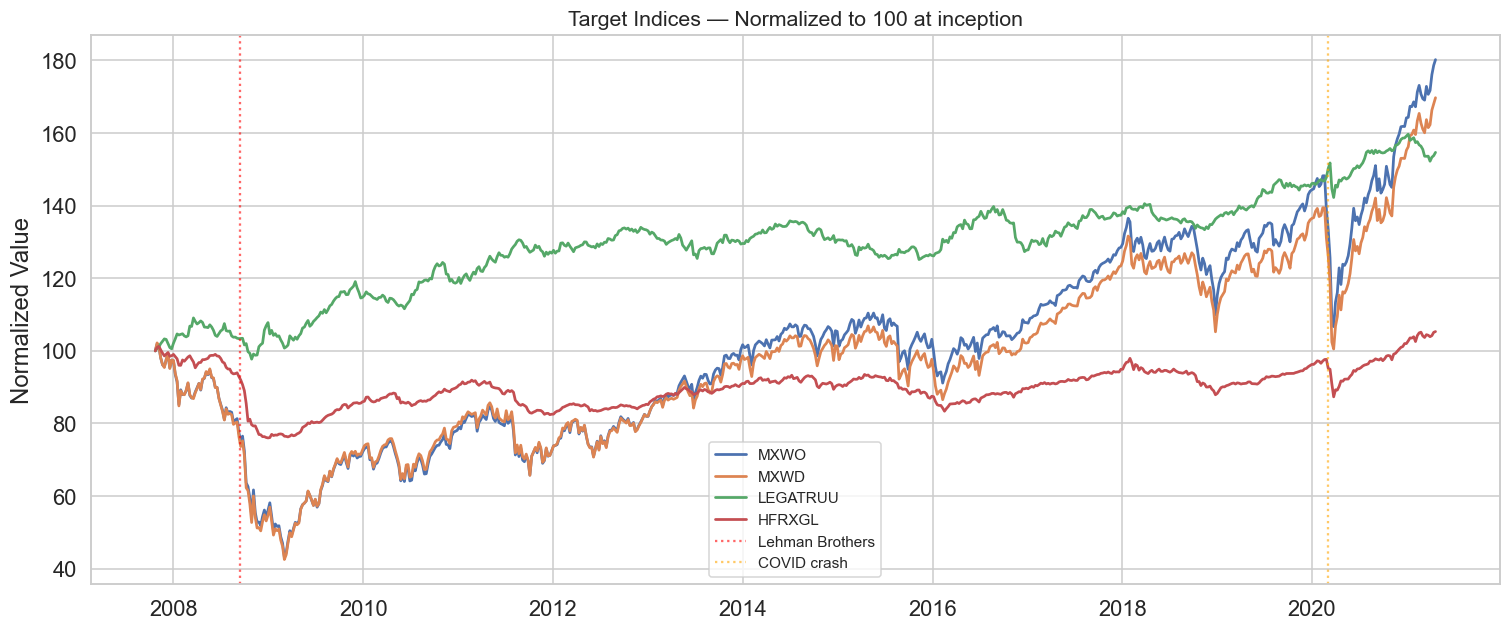

In [4]:
# ============================================================
# NORMALIZED PRICE SERIES
# ============================================================
plot_normalized_series(
    data=data,
    target_indices=target_indices,
    events={
        '2008-09-15': 'Lehman Brothers',
        '2020-03-01': 'COVID crash'
    }
)

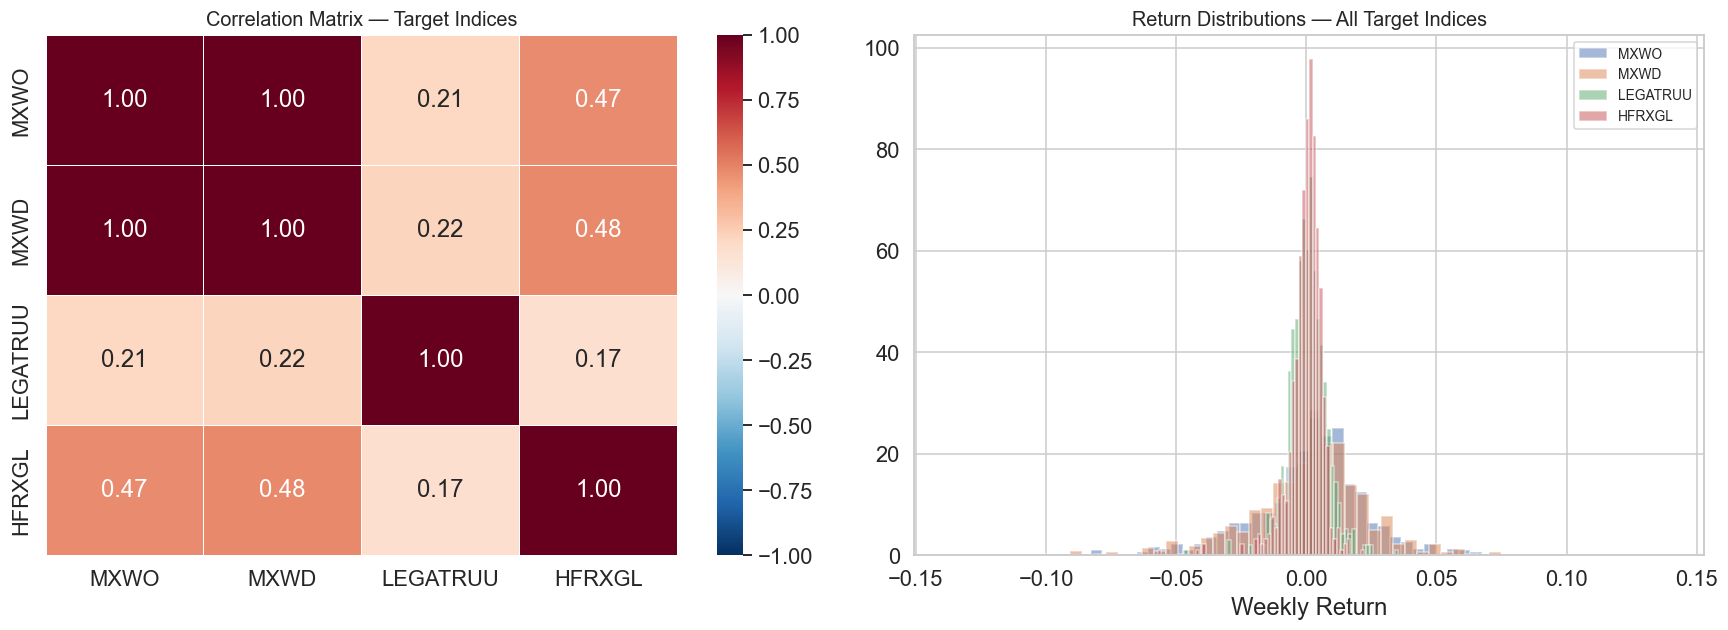

In [5]:
# ============================================================
# CORRELATION MATRIX + RETURN DISTRIBUTIONS
# ============================================================

# Plot the heatmap
plot_correlation_matrix(
    returns_df=target_returns,
    title='Correlation Matrix — Target Indices'
)

# Plot the grid of histograms
plot_return_distributions(
    returns_df=target_returns,
    indices=target_indices,
    cols=2 # You can easily change this to 3 if you add more indices later
)

### 2.2 Autocorrelation Analysis

Financial return series are theoretically close to a random walk (EMH). But autocorrelation in **squared returns** (volatility clustering) is almost universal in financial data. This has two implications for our model:

1. **Rolling window choice**: if returns are autocorrelated, shorter windows may overfit to a local regime; longer windows may dilute recent signals.
2. **VaR estimation**: if volatility clusters, a static Gaussian VaR computed over a long window will be miscalibrated during crisis periods.

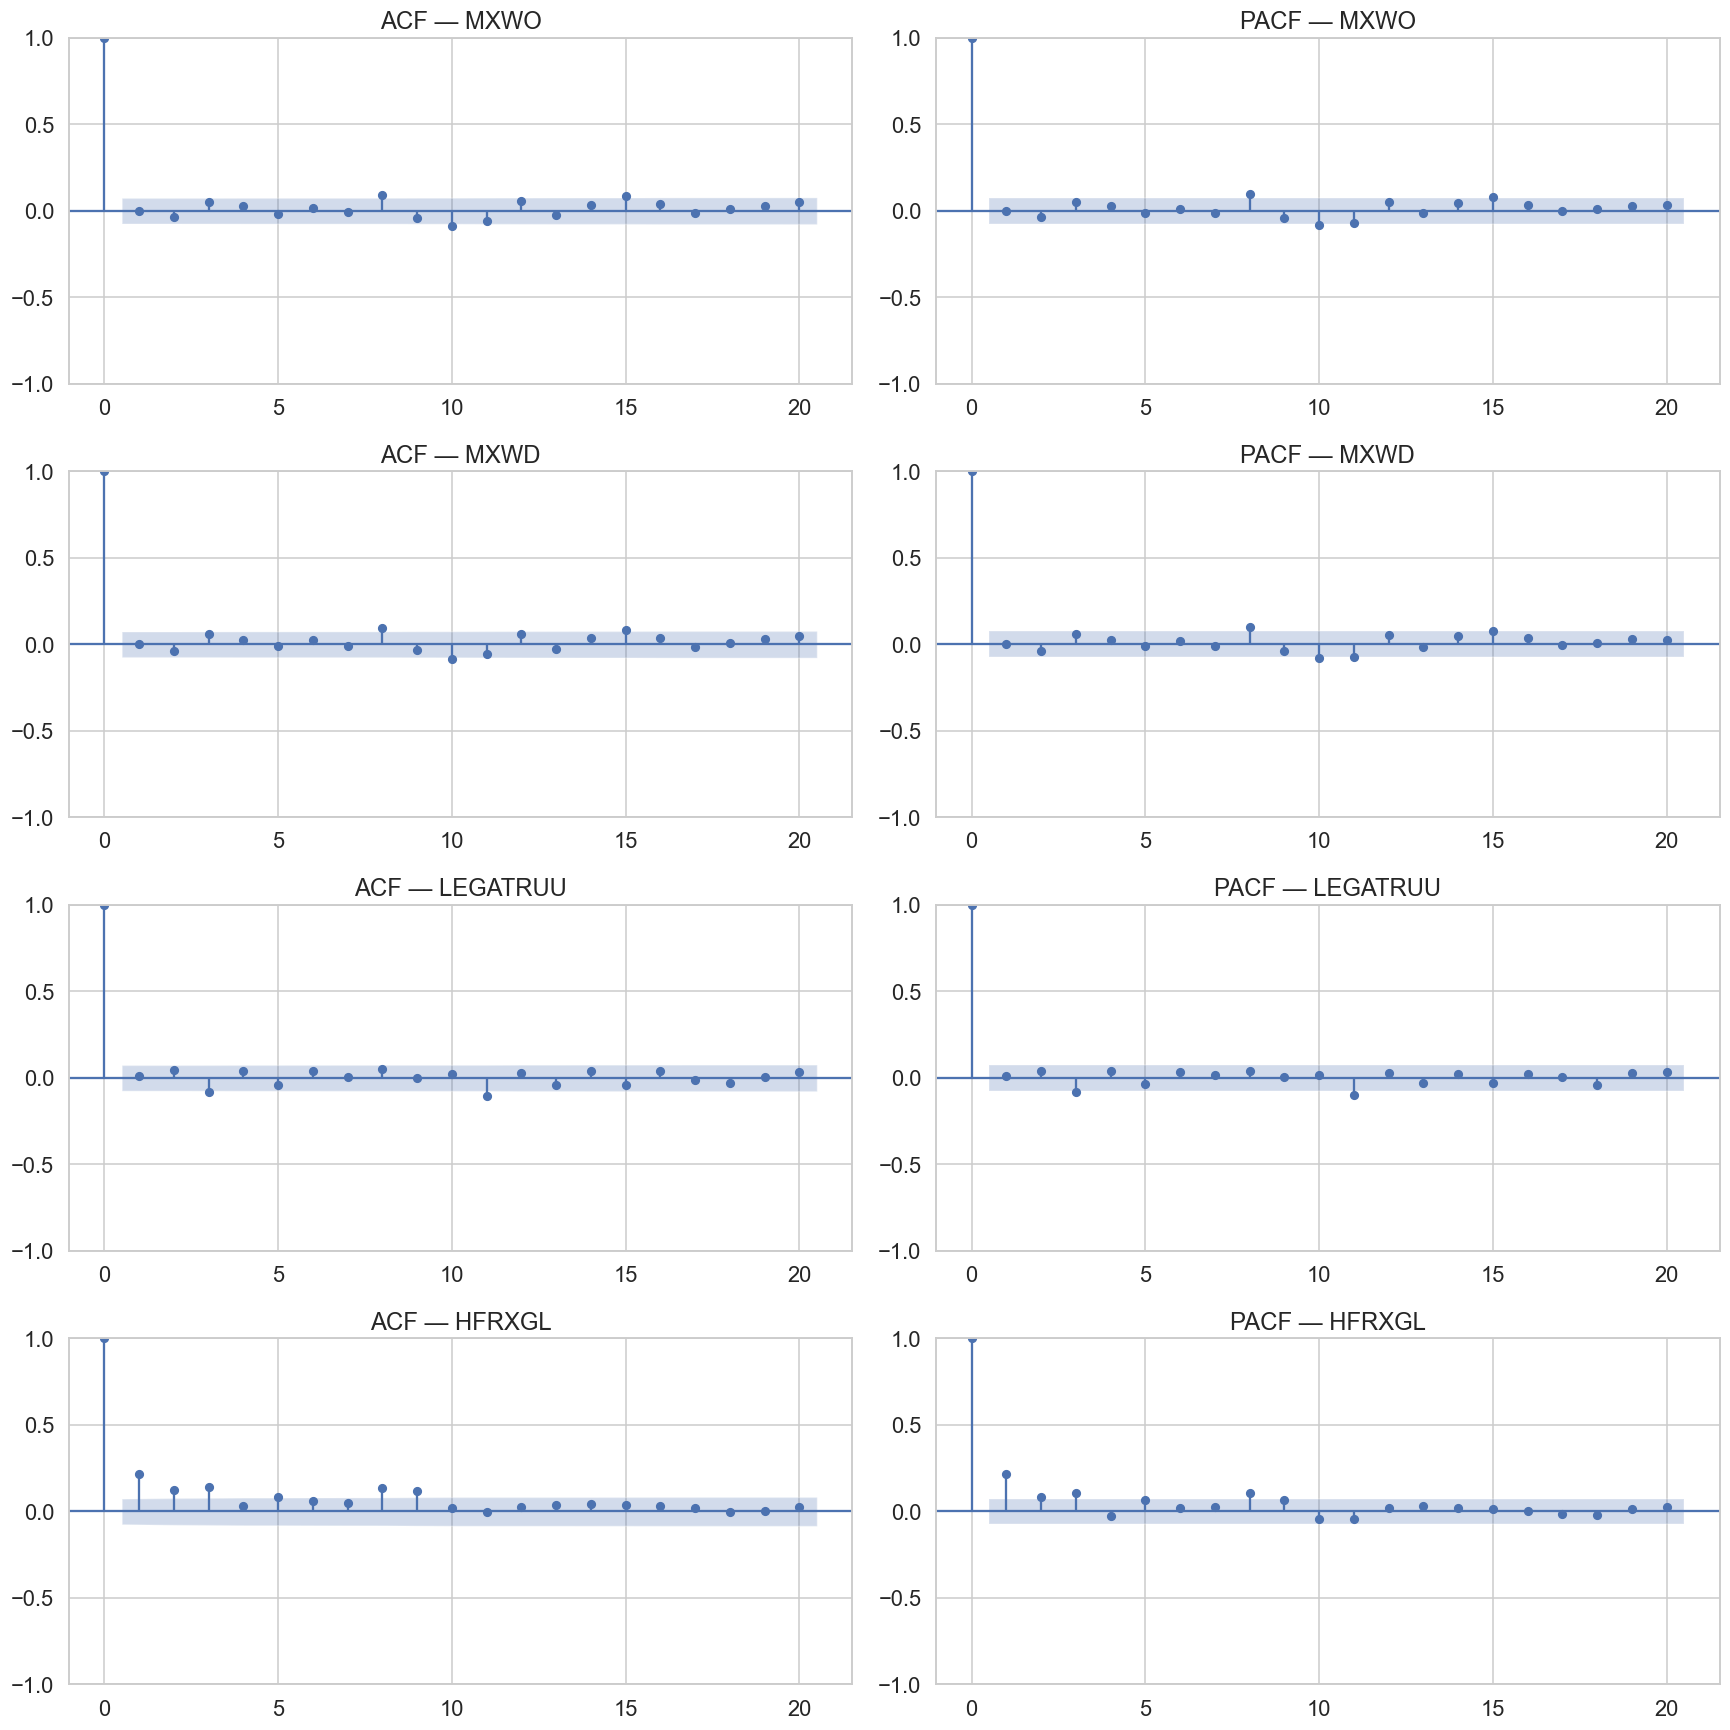


Ljung-Box test (H0: No autocorrelation in returns)
------------------------------------------------------------
MXWO                  lag5 p=0.590  lag10 p=0.091  lag20 p=0.052
MXWD                  lag5 p=0.539  lag10 p=0.065  lag20 p=0.043
LEGATRUU              lag5 p=0.136  lag10 p=0.307  lag20 p=0.148
HFRXGL                lag5 p=0.000  lag10 p=0.000  lag20 p=0.000

Ljung-Box test (H0: No autocorrelation in SQUARED returns — volatility clustering)
------------------------------------------------------------
MXWO                  lag5 p=0.000  lag10 p=0.000  lag20 p=0.000
MXWD                  lag5 p=0.000  lag10 p=0.000  lag20 p=0.000
LEGATRUU              lag5 p=0.000  lag10 p=0.000  lag20 p=0.000
HFRXGL                lag5 p=0.000  lag10 p=0.000  lag20 p=0.000


In [6]:
# ============================================================
# ACF / PACF + LJUNG-BOX TEST
# ============================================================
fig, axes = plt.subplots(len(target_indices), 2, figsize=(16, 4 * len(target_indices)))

for i, idx in enumerate(target_indices):
    r = target_returns[idx].dropna()
    plot_acf(r,  lags=20, ax=axes[i, 0], title=f'ACF — {idx}',  alpha=0.05)
    plot_pacf(r, lags=20, ax=axes[i, 1], title=f'PACF — {idx}', alpha=0.05)

plt.tight_layout()
plt.show()

# Ljung-Box test
print('\nLjung-Box test (H0: No autocorrelation in returns)')
print('-' * 60)
for idx in target_indices:
    lb = acorr_ljungbox(target_returns[idx].dropna(), lags=[5, 10, 20])
    pvals = lb['lb_pvalue'].values
    print(f'{idx:20s}  lag5 p={pvals[0]:.3f}  lag10 p={pvals[1]:.3f}  lag20 p={pvals[2]:.3f}')

print('\nLjung-Box test (H0: No autocorrelation in SQUARED returns — volatility clustering)')
print('-' * 60)
for idx in target_indices:
    lb = acorr_ljungbox(target_returns[idx].dropna()**2, lags=[5, 10, 20])
    pvals = lb['lb_pvalue'].values
    print(f'{idx:20s}  lag5 p={pvals[0]:.3f}  lag10 p={pvals[1]:.3f}  lag20 p={pvals[2]:.3f}')

---

## 3. Target Construction — The Monster Index

We construct a synthetic target index — a "monster" that is non-investable, multi-asset, and non-transparent. This simulates a real hedge fund of funds or a complex institutional portfolio.

**Composition:**
- 50% HFRXGL (Hedge Fund Index) — alternative, illiquid, opaque
- 25% MSCI World — developed equity
- 25% Global Aggregate Bond — fixed income

This combination is deliberately challenging to replicate:
- Hedge funds themselves hold thousands of positions across strategies
- Multi-currency exposure
- Non-linear option-like payoffs embedded in some hedge fund strategies

Our replication universe: **11 liquid Futures contracts** spanning equity, rates, commodities, and currencies.

In [7]:
# ============================================================
# CONSTRUCT MONSTER INDEX
# ============================================================

# ADJUSTED: Removed the ' Index' suffix to match the exact column names
index_components = {
    'HFRXGL':   0.50,
    'MXWO':     0.25,
    'LEGATRUU': 0.25
}

component_returns = returns[list(index_components.keys())]
monster_returns   = sum(component_returns[c] * w for c, w in index_components.items())
monster_returns.name = 'Monster Index'

# Align with futures
common_dates       = futures_returns.index.intersection(monster_returns.index)
futures_aligned    = futures_returns.loc[common_dates]
monster_aligned    = monster_returns.loc[common_dates]

# Monster index statistics
m_ann_ret = monster_aligned.mean() * annual_factor
m_ann_vol = monster_aligned.std() * np.sqrt(annual_factor)
m_cum     = (1 + monster_aligned).cumprod()
m_dd      = (m_cum / m_cum.cummax() - 1).min()

print('=== Monster Index Statistics ===')
print(f'  Annualized Return  : {m_ann_ret*100:.2f}%')
print(f'  Annualized Vol     : {m_ann_vol*100:.2f}%')
print(f'  Sharpe Ratio       : {m_ann_ret/m_ann_vol:.2f}')
print(f'  Max Drawdown       : {m_dd*100:.2f}%')
print(f'  Skewness           : {monster_aligned.skew():.3f}')
print(f'  Excess Kurtosis    : {monster_aligned.kurtosis():.3f}')

# Correlations with futures
corr_with_monster = futures_aligned.corrwith(monster_aligned).sort_values(key=abs, ascending=False)
print('\n=== Futures Correlation with Monster Index (sorted by |ρ|) ===')
display(corr_with_monster.rename('Correlation').to_frame())

=== Monster Index Statistics ===
  Annualized Return  : 2.57%
  Annualized Vol     : 6.33%
  Sharpe Ratio       : 0.41
  Max Drawdown       : -29.01%
  Skewness           : -1.345
  Excess Kurtosis    : 7.644

=== Futures Correlation with Monster Index (sorted by |ρ|) ===


,Correlation
ES1,0.837925
NQ1,0.746908
VG1,0.730608
TP1,0.598764
LLL1,0.498685
CO1,0.444804
DU1,-0.261666
GC1,0.218268
TU2,-0.152824
RX1,-0.130681


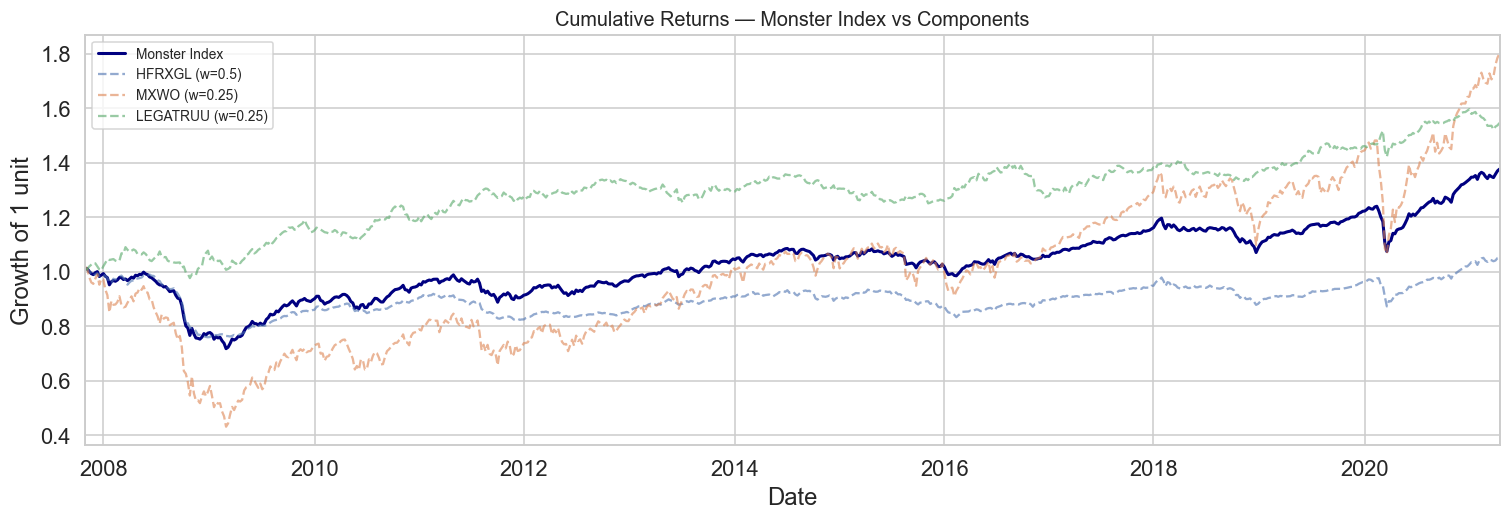

In [8]:
# ============================================================
# CUMULATIVE RETURN PLOT
# ============================================================

plot_cumulative_returns(
    main_cum=m_cum,
    component_returns=returns,
    components_dict=index_components,
    dates=common_dates
)

---

## 4. Baseline — OLS Regression (Static)

Before introducing complexity, we start with the simplest possible approach: ordinary least squares (OLS) estimated once on the full dataset. This is **not deployable** (it uses future data) but gives us a ceiling — the best linear fit we could possibly achieve — and helps understand which futures matter.

**Why OLS is insufficient in practice:**
- It uses the entire history, violating the out-of-sample requirement
- With 11 correlated predictors and ~700 observations, it may overfit
- It imposes no portfolio constraints (leverage, sparsity)
- Weights are static — they don't adapt as market regimes change

=== OLS Static (In-Sample, Full History) ===
  Tracking Error (ann.)  : 2.93%
  Correlation            : 0.8863
  R²                     : 0.7856
  Gross Exposure         : 1.00x

OLS Weights:


,Weight
DU1,-0.2873
ES1,0.2484
TY1,0.1706
RX1,0.0657
TU2,0.0562
VG1,0.0533
TP1,0.0448
GC1,0.0354
NQ1,-0.0204
CO1,0.0117


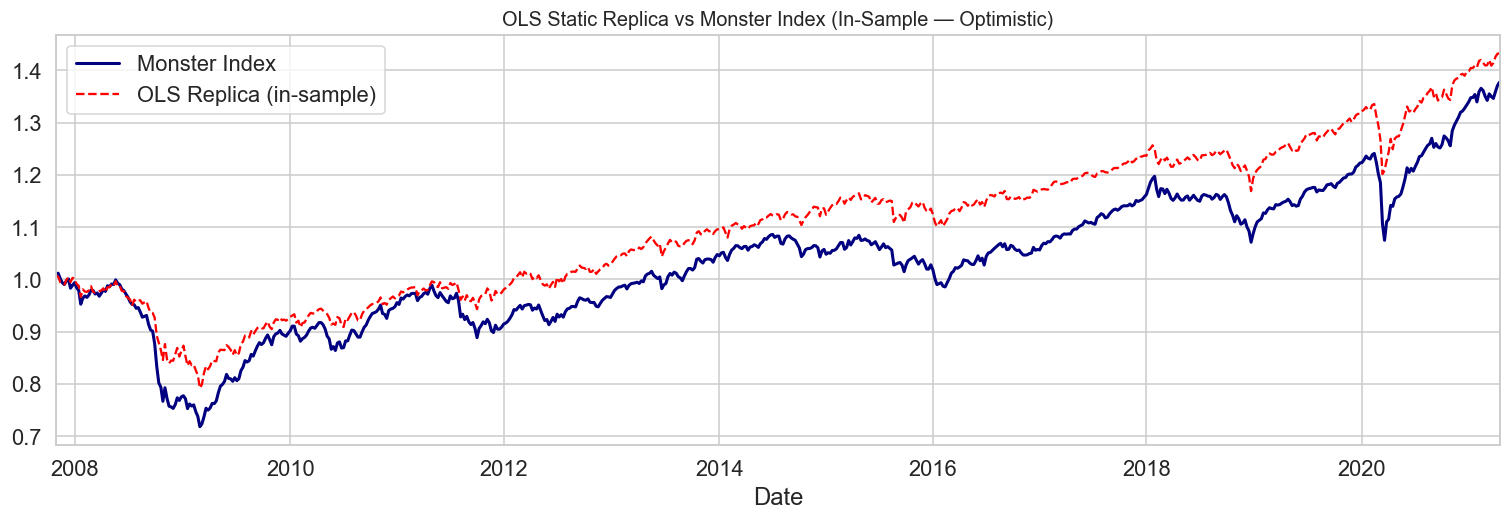

In [9]:
# main.py (or your Jupyter Notebook)

from sklearn.linear_model import LinearRegression
# Ensure you import your new function
from plots import plot_replica_vs_target

# ============================================================
# STATIC OLS — FULL SAMPLE (UPPER BOUND)
# ============================================================

# 1. Fit the Model
ols = LinearRegression(fit_intercept=False)
ols.fit(futures_aligned.values, monster_aligned.values)

ols_weights = pd.Series(ols.coef_, index=futures_aligned.columns)
ols_replica = futures_aligned @ ols_weights

# 2. Calculate & Print Metrics
te_insample = (ols_replica - monster_aligned).std() * np.sqrt(annual_factor)
corr_insample = ols_replica.corr(monster_aligned)

print('=== OLS Static (In-Sample, Full History) ===')
print(f'  Tracking Error (ann.)  : {te_insample*100:.2f}%')
print(f'  Correlation            : {corr_insample:.4f}')
print(f'  R²                     : {ols.score(futures_aligned, monster_aligned):.4f}')
print(f'  Gross Exposure         : {ols_weights.abs().sum():.2f}x')

print('\nOLS Weights:')
display(ols_weights.sort_values(key=abs, ascending=False).to_frame('Weight').round(4))

# 3. Plot the Results
plot_replica_vs_target(
    target_returns=monster_aligned,
    replica_returns=ols_replica,
    target_label='Monster Index',
    replica_label='OLS Replica (in-sample)',
    title='OLS Static Replica vs Monster Index (In-Sample — Optimistic)'
)

---

## 5. Regularized Rolling Backtest

### 5.1 Why Regularization?

OLS minimizes $\|y - X\beta\|^2$ with no constraints on $\beta$. With correlated predictors (and all futures indices are correlated), OLS weights can be large and unstable — producing high turnover and leverage. Regularization adds a penalty to control this:

$$\min_\beta \left\{ \|y - X\beta\|^2 + \lambda \left[ \alpha \|\beta\|_1 + (1-\alpha)\|\beta\|_2^2 \right] \right\}$$

- **Ridge** ($\alpha=0$): shrinks all weights toward zero, keeps all assets, handles multicollinearity
- **Lasso** ($\alpha=1$): drives some weights exactly to zero → sparse portfolio, fewer trades
- **Elastic Net** ($0 < \alpha < 1$): best of both — sparsity + stability

In portfolio terms: Lasso's sparsity maps directly to lower transaction costs (fewer positions to rebalance). Ridge's stability means weights don't swing wildly between rebalancing dates.

### 5.2 Why Rolling Windows?

Financial markets are non-stationary. The correlation between a hedge fund index and equity futures in 2008 (crisis, correlation spike) is completely different from 2015 (low volatility, decorrelation). A static model trained on all history will average across regimes and perform poorly in any specific regime.

A **rolling window** approach:
1. At time $t$, train on the last $K$ weeks
2. Predict the return at $t+1$ using estimated weights
3. Advance one week and repeat

This is the standard **backtesting** approach in quantitative finance. It gives a realistic simulation of how the strategy would have performed in real deployment.

### 5.3 VaR Scaling

Under UCITS/MiFID, the maximum monthly VaR at 99% confidence is 20%. We enforce this by:
1. Estimating the portfolio VaR from recent replica returns
2. If VaR > threshold, scaling all weights down proportionally

We use a **t-distribution VaR** (instead of Gaussian) to better capture fat tails observed in the data.

In [10]:
from Backtest import var_t


# ============================================================
# VAR UTILITIES
# ============================================================
def var_gaussian(returns_series, confidence=0.01, horizon=4):
    """Gaussian parametric VaR (standard but underestimates fat tails)."""
    sigma = np.std(returns_series)
    z = stats.norm.ppf(confidence)
    return -z * sigma * np.sqrt(horizon)

def historical_var(returns_series, confidence=0.01, horizon=4):
    """
    Historical simulation VaR.
    No distributional assumptions — reads directly from empirical quantile.
    Most robust but requires sufficient history.
    """
    q = np.quantile(returns_series, confidence)
    return -q * np.sqrt(horizon)

# Compare VaR methods on Monster Index
print('=== VaR Comparison on Monster Index (1%, 1-month horizon) ===')
print(f'  Gaussian VaR    : {var_gaussian(monster_aligned)*100:.2f}%')
print(f'  Student-t VaR   : {var_t(monster_aligned)*100:.2f}%')
print(f'  Historical VaR  : {historical_var(monster_aligned)*100:.2f}%')
print('\n  → Student-t and Historical VaR are larger, reflecting fat tails.')
print('  → We will use Student-t VaR for the rolling backtest.')

=== VaR Comparison on Monster Index (1%, 1-month horizon) ===
  Gaussian VaR    : 4.08%
  Student-t VaR   : 4.46%
  Historical VaR  : 5.41%

  → Student-t and Historical VaR are larger, reflecting fat tails.
  → We will use Student-t VaR for the rolling backtest.


# RollingBacktester — Technical Documentation

## 1. Objective

The `RollingBacktester` simulates a dynamic portfolio strategy with:

- Rolling window re-estimation
- Periodic rebalancing
- Transaction costs
- VaR-based risk control
- Out-of-sample evaluation

---

## 2. Portfolio Model

At each time \( t \):

$$
r_t^{p} = x_t^\top w_t
$$

Where:
- \( x_t \): asset returns
- \( w_t \): portfolio weights

---

## 3. Rolling Estimation

Using a rolling window \( W \):

$$
(X_{t-W:t}, y_{t-W:t})
$$

We assume a linear model:

$$
y = X\beta + \epsilon
$$

Weights are obtained and rescaled:

$$
w = \frac{\hat{\beta}}{\sigma_X}
$$

---

## 4. Rebalancing Rule

Rebalancing occurs every \( R \) steps:

$$
t \equiv 0 \ (\text{mod } R)
$$

Otherwise:
- weights remain unchanged

---

## 5. Transaction Costs

Turnover:

$$
\text{turnover}_t = \sum_i |w_{t,i} - w_{t-1,i}|
$$

Transaction cost:

$$
TC_t = \text{turnover}_t \cdot \frac{\text{bps}}{10{,}000}
$$

Net return:

$$
r_t^{net} = r_t - TC_t
$$

---

## 6. VaR Risk Control

Value-at-Risk:

$$
VaR_t = Q_{\alpha}(r_{t-52:t})
$$

If:

$$
VaR_t > \text{threshold}
$$

Then scaling is applied:

$$
w_t \leftarrow w_t \cdot \frac{\text{threshold}}{VaR_t}
$$

---

## 7. Tracking Error

$$
TE = \sigma(r^{p} - r^{target}) \cdot \sqrt{A}
$$

Where:
- \( A = 52 \)

---

## 8. Outputs

The backtester returns:

- `replica` (gross returns)
- `replica_net` (net returns)
- `weights` (portfolio paths)
- `var` (risk series)

---

## 9. Algorithm Flow

1. Fit model on rolling window
2. Estimate weights
3. Apply VaR constraint
4. Compute turnover + transaction costs
5. Generate portfolio returns
6. Store outputs

---

## 10. Interpretation

This framework models:

- Dynamic portfolio construction
- Realistic trading frictions
- Risk-managed allocation
- Out-of-sample evaluation under constraints

In [11]:
from Backtest import RollingBacktester

bt = RollingBacktester(rolling_window=104)

### 5.4 Hyperparameter Selection via Time-Series Cross-Validation

We use **TimeSeriesSplit** (sklearn) for cross-validation rather than standard k-fold. Standard k-fold would mix future and past data — a form of look-ahead bias. TimeSeriesSplit always trains on the past and validates on the future, respecting the temporal structure of the data.

We search over:
- **α (Elastic Net l1_ratio)**: controls sparsity vs stability
- **λ (alpha in sklearn)**: controls regularization strength
- **Rolling window K**: controls how much history the model uses

Objective: minimize **Tracking Error** on the validation fold.

In [12]:
from Backtest import HyperparameterOptimizer

optimizer = HyperparameterOptimizer(bt, futures_aligned, monster_aligned)

param_grid = {
    "alpha": [1e-4, 1e-3, 1e-2,
              #5e-2
              ],
    "l1_ratio": [0.0, 0.3, 0.5, 0.7, 1.0]
}

cv_df, best_params, best_te = optimizer.grid_search(ElasticNet, param_grid)

print(cv_df.head())
print("Best:", best_params)

    alpha  l1_ratio        TE
0  0.0001       0.0  0.044300
1  0.0010       0.0  0.044403
2  0.0001       0.3  0.044946
3  0.0001       0.5  0.045226
4  0.0100       0.0  0.045283
Best: {'alpha': np.float64(0.0001), 'l1_ratio': np.float64(0.0)}


In [13]:
from Backtest import ModelRunner

runner = ModelRunner(bt, futures_aligned, monster_aligned)

models = {
    "Ridge": Ridge(alpha=best_params["alpha"], fit_intercept=False),
    "Lasso": Lasso(alpha=best_params["alpha"], fit_intercept=False, max_iter=200),
    "ElasticNet": ElasticNet(
        alpha=best_params["alpha"],
        l1_ratio=best_params["l1_ratio"],
        fit_intercept=False,
        max_iter=200
    )
}

results = runner.run_models(models)

print("All models trained.")

All models trained.


In [15]:
# ============================================================
# METRICS TABLE (UNIFIED NET-BASED FRAMEWORK)
# ============================================================

# Build performance table from unified metrics
metrics_table = pd.DataFrame({
    name: res["metrics"] for name, res in results.items()
}).T.round(3)

print("=== Out-of-Sample Performance (Net-aware evaluation) ===")
display(metrics_table)

=== Out-of-Sample Performance (Net-aware evaluation) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,3.363,4.958,2.807,0.866,-0.182,1.883
Lasso,3.549,4.818,2.844,0.862,-0.114,1.277
ElasticNet,3.364,4.958,2.807,0.866,-0.181,1.883


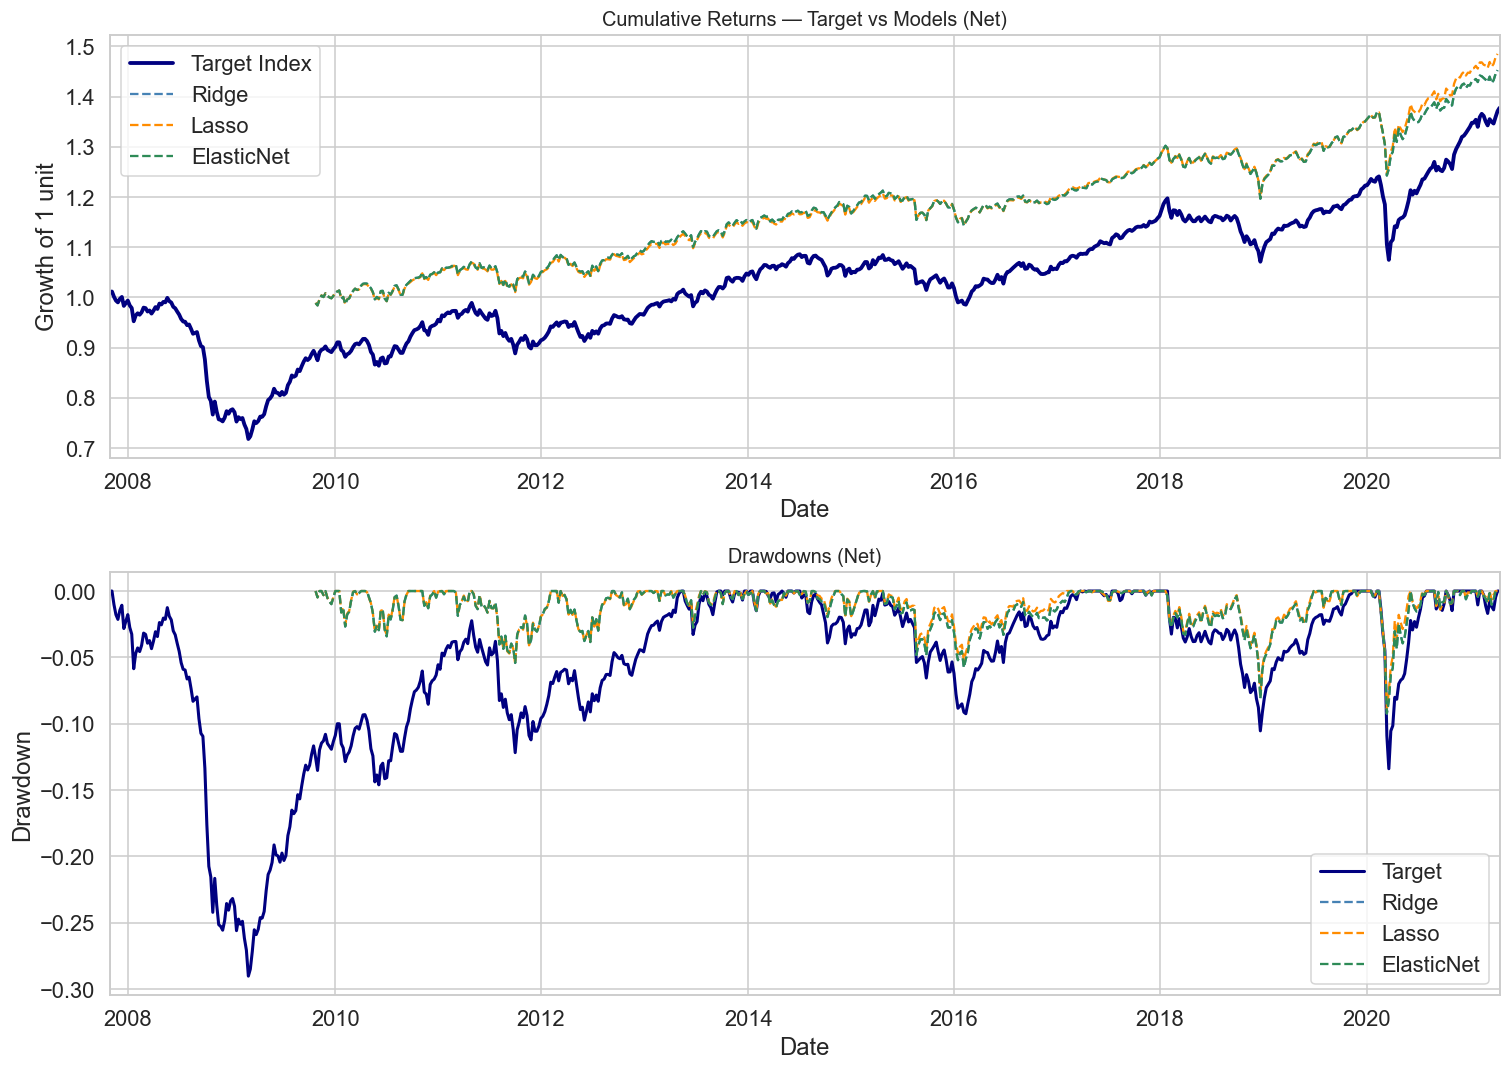

In [19]:
import matplotlib.pyplot as plt

# ============================================================
# CUMULATIVE RETURN COMPARISON (FIXED MAIN SCRIPT)
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = {
    'Ridge': 'steelblue',
    'Lasso': 'darkorange',
    'ElasticNet': 'seagreen'
}

# ------------------------------------------------------------
# Target series (from your dataset, NOT results)
# ------------------------------------------------------------
target = monster_aligned
target_cum = (1 + target).cumprod()

target_cum.plot(
    ax=axes[0],
    color='navy',
    lw=2.5,
    label='Target Index'
)

# ------------------------------------------------------------
# Model cumulative returns (NET)
# ------------------------------------------------------------
for name, res in results.items():
    rep = res["replica_net"]

    (1 + rep).cumprod().plot(
        ax=axes[0],
        lw=1.5,
        linestyle='--',
        color=colors.get(name, None),
        label=name
    )

axes[0].set_title('Cumulative Returns — Target vs Models (Net)', fontsize=13)
axes[0].set_ylabel('Growth of 1 unit')
axes[0].legend()

# ------------------------------------------------------------
# Drawdown function
# ------------------------------------------------------------
def drawdown(series):
    cum = (1 + series).cumprod()
    return cum / cum.cummax() - 1

# Target drawdown
drawdown(target).plot(
    ax=axes[1],
    color='navy',
    lw=2,
    label='Target'
)

# Model drawdowns (NET)
for name, res in results.items():
    drawdown(res["replica_net"]).plot(
        ax=axes[1],
        lw=1.5,
        linestyle='--',
        color=colors.get(name, None),
        label=name
    )

axes[1].set_title('Drawdowns (Net)', fontsize=13)
axes[1].set_ylabel('Drawdown')
axes[1].legend()

plt.tight_layout()
plt.show()

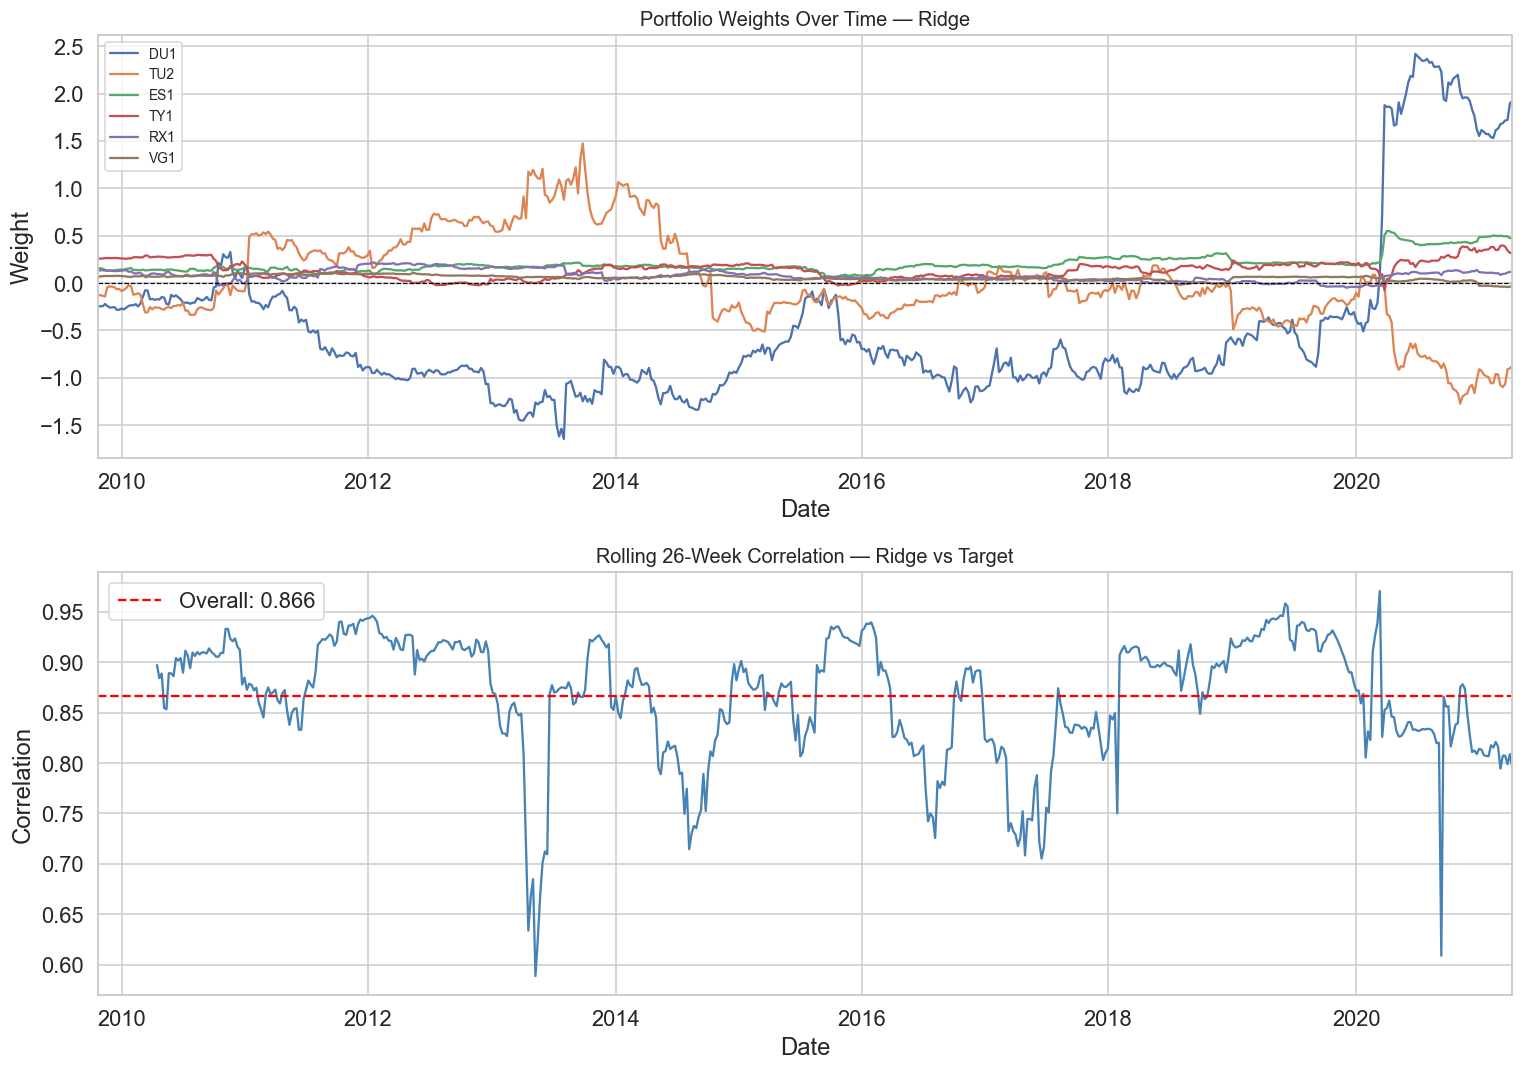

In [21]:
import matplotlib.pyplot as plt

# ============================================================
# WEIGHT EVOLUTION + ROLLING CORRELATION (FIXED)
# ============================================================

best_model_name = metrics_table['Tracking Error (%)'].idxmin()
best_res = results[best_model_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ------------------------------------------------------------
# WEIGHT EVOLUTION
# ------------------------------------------------------------
weights = best_res["weights"]

top_cols = (
    weights.abs()
    .mean()
    .sort_values(ascending=False)
    .head(6)
    .index
)

weights[top_cols].plot(ax=axes[0])

axes[0].set_title(f'Portfolio Weights Over Time — {best_model_name}', fontsize=13)
axes[0].set_ylabel('Weight')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].legend(fontsize=9)

# ------------------------------------------------------------
# ROLLING CORRELATION (NET VERSION)
# ------------------------------------------------------------
rep = best_res["replica_net"]
target = monster_aligned.loc[rep.index]  # ensure alignment

roll_corr = rep.rolling(26).corr(target)

roll_corr.plot(ax=axes[1], color='steelblue', lw=1.5)

axes[1].axhline(
    best_res["metrics"]["Correlation"],
    color='red',
    linestyle='--',
    label=f"Overall: {best_res['metrics']['Correlation']:.3f}"
)

axes[1].set_title(
    f'Rolling 26-Week Correlation — {best_model_name} vs Target',
    fontsize=13
)

axes[1].set_ylabel('Correlation')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 6. Kalman Filter — Dynamic Weight Estimation

### 6.1 Motivation

The rolling Elastic Net reestimates weights from scratch every week on a fixed window. This has two weaknesses:
- **Discontinuous updates**: weights jump at each rebalancing
- **Symmetric memory**: all observations in the window receive equal weight, regardless of recency

The **Kalman Filter** solves both problems by treating portfolio weights as **latent states** that evolve continuously over time. It is the optimal linear estimator for state-space models under Gaussian noise — and in finance it has a long history in factor model estimation and hedge fund replication.

### 6.2 State-Space Formulation

We model the system as:

**State equation** (weights follow a random walk):
$$\beta_t = \beta_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, Q)$$

**Observation equation** (returns are a linear function of weights):
$$y_t = x_t^\top \beta_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, R)$$

where:
- $\beta_t$ = portfolio weights (unobservable, time-varying)
- $x_t$ = futures returns at time $t$ (observable)
- $y_t$ = target return at time $t$ (observable)
- $Q$ = process noise covariance (how fast weights can change)
- $R$ = observation noise variance (how noisy target returns are)

### 6.3 Kalman Recursion

At each step $t$, the filter runs two stages:

**Predict:**
$$\hat{\beta}_{t|t-1} = \hat{\beta}_{t-1|t-1}$$
$$P_{t|t-1} = P_{t-1|t-1} + Q$$

**Update** (when new observation $y_t$ arrives):
$$K_t = P_{t|t-1} x_t \left(x_t^\top P_{t|t-1} x_t + R\right)^{-1} \quad \text{(Kalman gain)}$$
$$\hat{\beta}_{t|t} = \hat{\beta}_{t|t-1} + K_t \left(y_t - x_t^\top \hat{\beta}_{t|t-1}\right)$$
$$P_{t|t} = (I - K_t x_t^\top) P_{t|t-1}$$

The **Kalman gain** $K_t$ balances how much to trust the prediction vs. the new observation. High process noise $Q$ → trust new data more. High observation noise $R$ → trust the prior more.

### 6.4 Initialization

We initialize $\hat{\beta}_0$ using Ridge regression on the first rolling window, giving the Kalman Filter a sensible starting point rather than zero weights.

In [25]:
import importlib
import Kalman_Filter

importlib.reload(Kalman_Filter)
from Kalman_Filter import KalmanFilterStrategy

# ============================================================
# KALMAN PARAMETER TUNING (MODERN VERSION)
# ============================================================

kf_results = {}
pn_grid = [1e-5, 1e-4, 5e-4, 1e-3]

for pn in pn_grid:

    # --------------------------------------------------------
    # Create strategy instance
    # --------------------------------------------------------
    kf = KalmanFilterStrategy(
        init_window=104,
        process_noise=pn,
        transaction_cost_bps=5.0
    )

    # --------------------------------------------------------
    # Run through unified framework
    # --------------------------------------------------------
    res = runner.run_models({"Kalman": kf})["Kalman"]

    # --------------------------------------------------------
    # Extract metrics
    # --------------------------------------------------------
    te = res["metrics"]["Tracking Error (%)"]
    corr = res["metrics"]["Correlation"]

    kf_results[pn] = res

    print(
        f'process_noise={pn:.0e}  |  '
        f'TE={te:.2f}%  |  '
        f'Corr={corr:.4f}'
    )

# ============================================================
# SELECT BEST PARAMETER
# ============================================================

best_pn = min(
    kf_results,
    key=lambda k: kf_results[k]["metrics"]["Tracking Error (%)"]
)

best_kalman = KalmanFilterStrategy(
    init_window=104,
    process_noise=best_pn,
    transaction_cost_bps=5.0
)

print(f"\nBest process_noise: {best_pn:.0e}")

# Add to final model pool
models["Kalman"] = best_kalman

process_noise=1e-05  |  TE=2.87%  |  Corr=0.8595
process_noise=1e-04  |  TE=2.99%  |  Corr=0.8491
process_noise=5e-04  |  TE=3.07%  |  Corr=0.8419
process_noise=1e-03  |  TE=3.13%  |  Corr=0.8366

Best process_noise: 1e-05


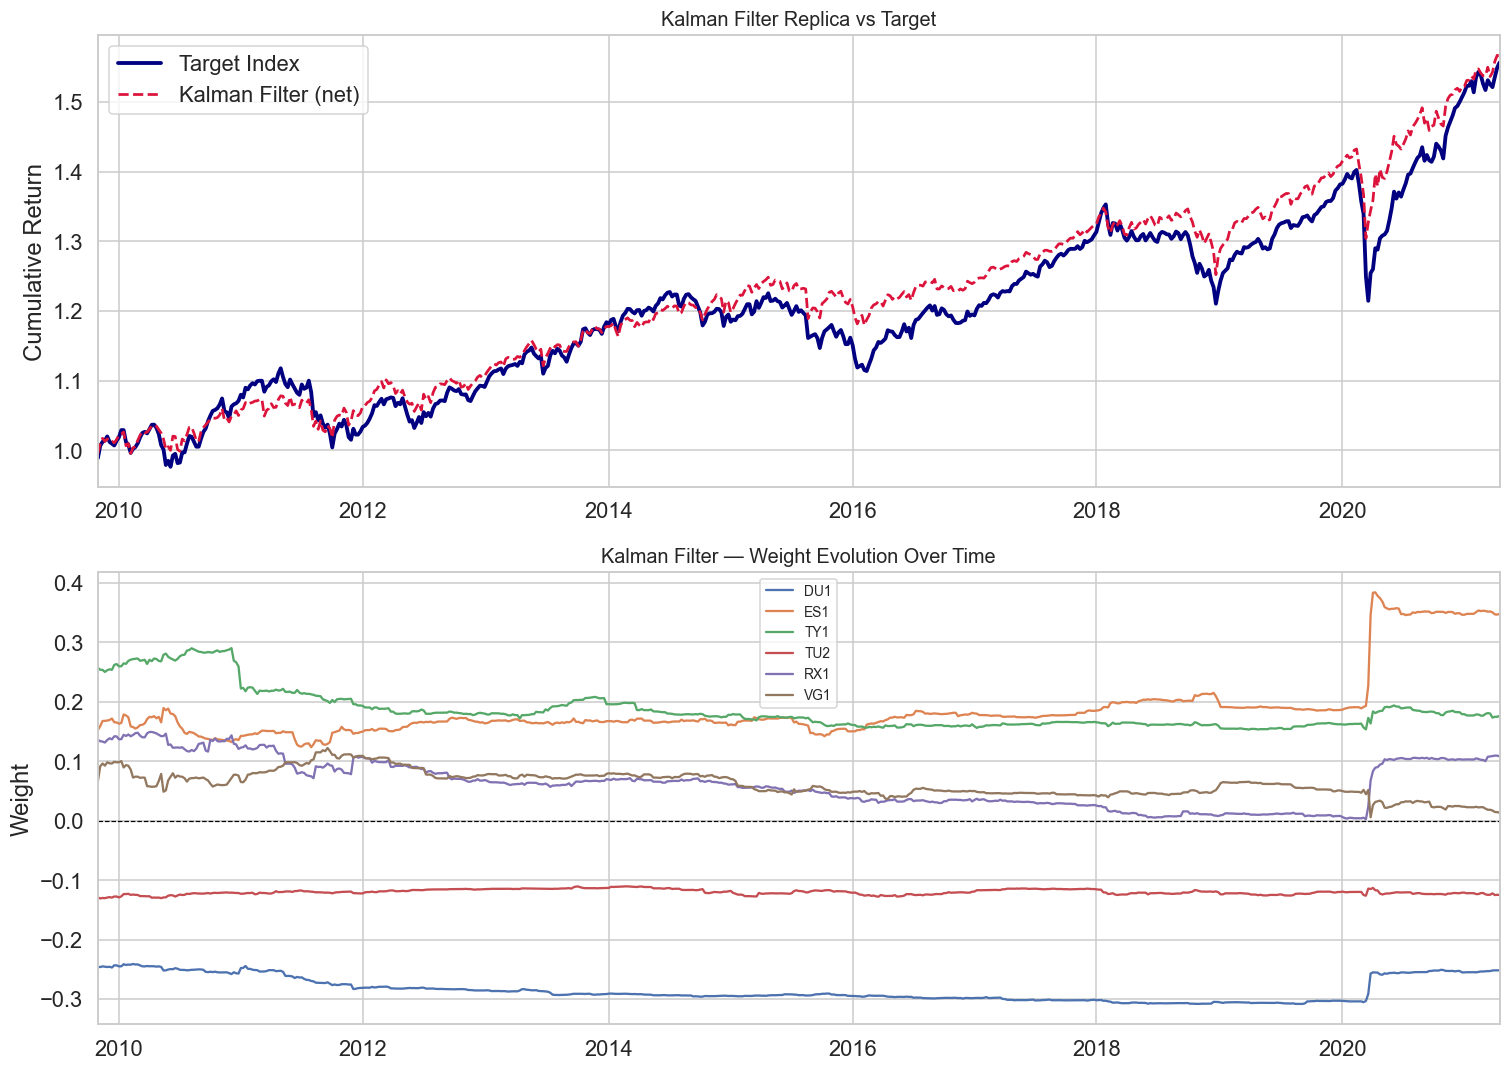

In [30]:
results = runner.run_models(models)
kf_res = results["Kalman"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ------------------------------------------------------------
# TARGET (SAFE FALLBACK)
# ------------------------------------------------------------
if "target" in kf_res:
    target = kf_res["target"]
else:
    target = runner.y.loc[kf_res["replica_net"].index]

# ------------------------------------------------------------
# CUMULATIVE RETURNS (NET)
# ------------------------------------------------------------
(1 + target).cumprod().plot(
    ax=axes[0],
    color='navy',
    lw=2.5,
    label='Target Index'
)

(1 + kf_res["replica_net"]).cumprod().plot(
    ax=axes[0],
    color='crimson',
    lw=1.8,
    linestyle='--',
    label='Kalman Filter (net)'
)

axes[0].set_title('Kalman Filter Replica vs Target', fontsize=13)
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()

# ------------------------------------------------------------
# WEIGHT EVOLUTION
# ------------------------------------------------------------
weights = kf_res["weights"]

top_kf = (
    weights.abs()
    .mean()
    .sort_values(ascending=False)
    .head(6)
    .index
)

weights[top_kf].plot(ax=axes[1])

axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Kalman Filter — Weight Evolution Over Time', fontsize=13)
axes[1].set_ylabel('Weight')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 7. Full Model Comparison

We now compare all four approaches: Ridge, Lasso, Elastic Net, and Kalman Filter — both gross and net of transaction costs.

**Key metrics to interpret:**

| Metric | What it measures | Better is |
|---|---|---|
| **Tracking Error** | Annualized std of (replica − target) | Lower |
| **Correlation** | Linear co-movement with target | Higher |
| **Information Ratio** | Excess return per unit of tracking error | Higher |
| **Gross Exposure** | Sum of absolute weights (leverage) | Context-dependent |
| **Max Drawdown** | Worst peak-to-trough loss | Lower |

In [33]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

all_metrics = pd.DataFrame({
    name: res["metrics"]
    for name, res in results.items()
}).T.round(3)

# ------------------------------------------------------------
# SAFE NET METRICS (only if available)
# ------------------------------------------------------------
all_metrics_net = pd.DataFrame({
    name: res["metrics_net"]
    for name, res in results.items()
    if "metrics_net" in res
}).T.round(3)

print("=== GROSS Performance (before transaction costs) ===")
display(all_metrics)

if not all_metrics_net.empty:
    print("\n=== NET Performance (after transaction costs) ===")
    display(all_metrics_net)
else:
    print("\n=== NET Performance not available for all models ===")

=== GROSS Performance (before transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,3.363,4.958,2.807,0.866,-0.182,1.883
Lasso,3.549,4.818,2.844,0.862,-0.114,1.277
ElasticNet,3.364,4.958,2.807,0.866,-0.181,1.883
Kalman,4.025,4.999,2.873,0.860,0.009,1.060



=== NET Performance not available for all models ===


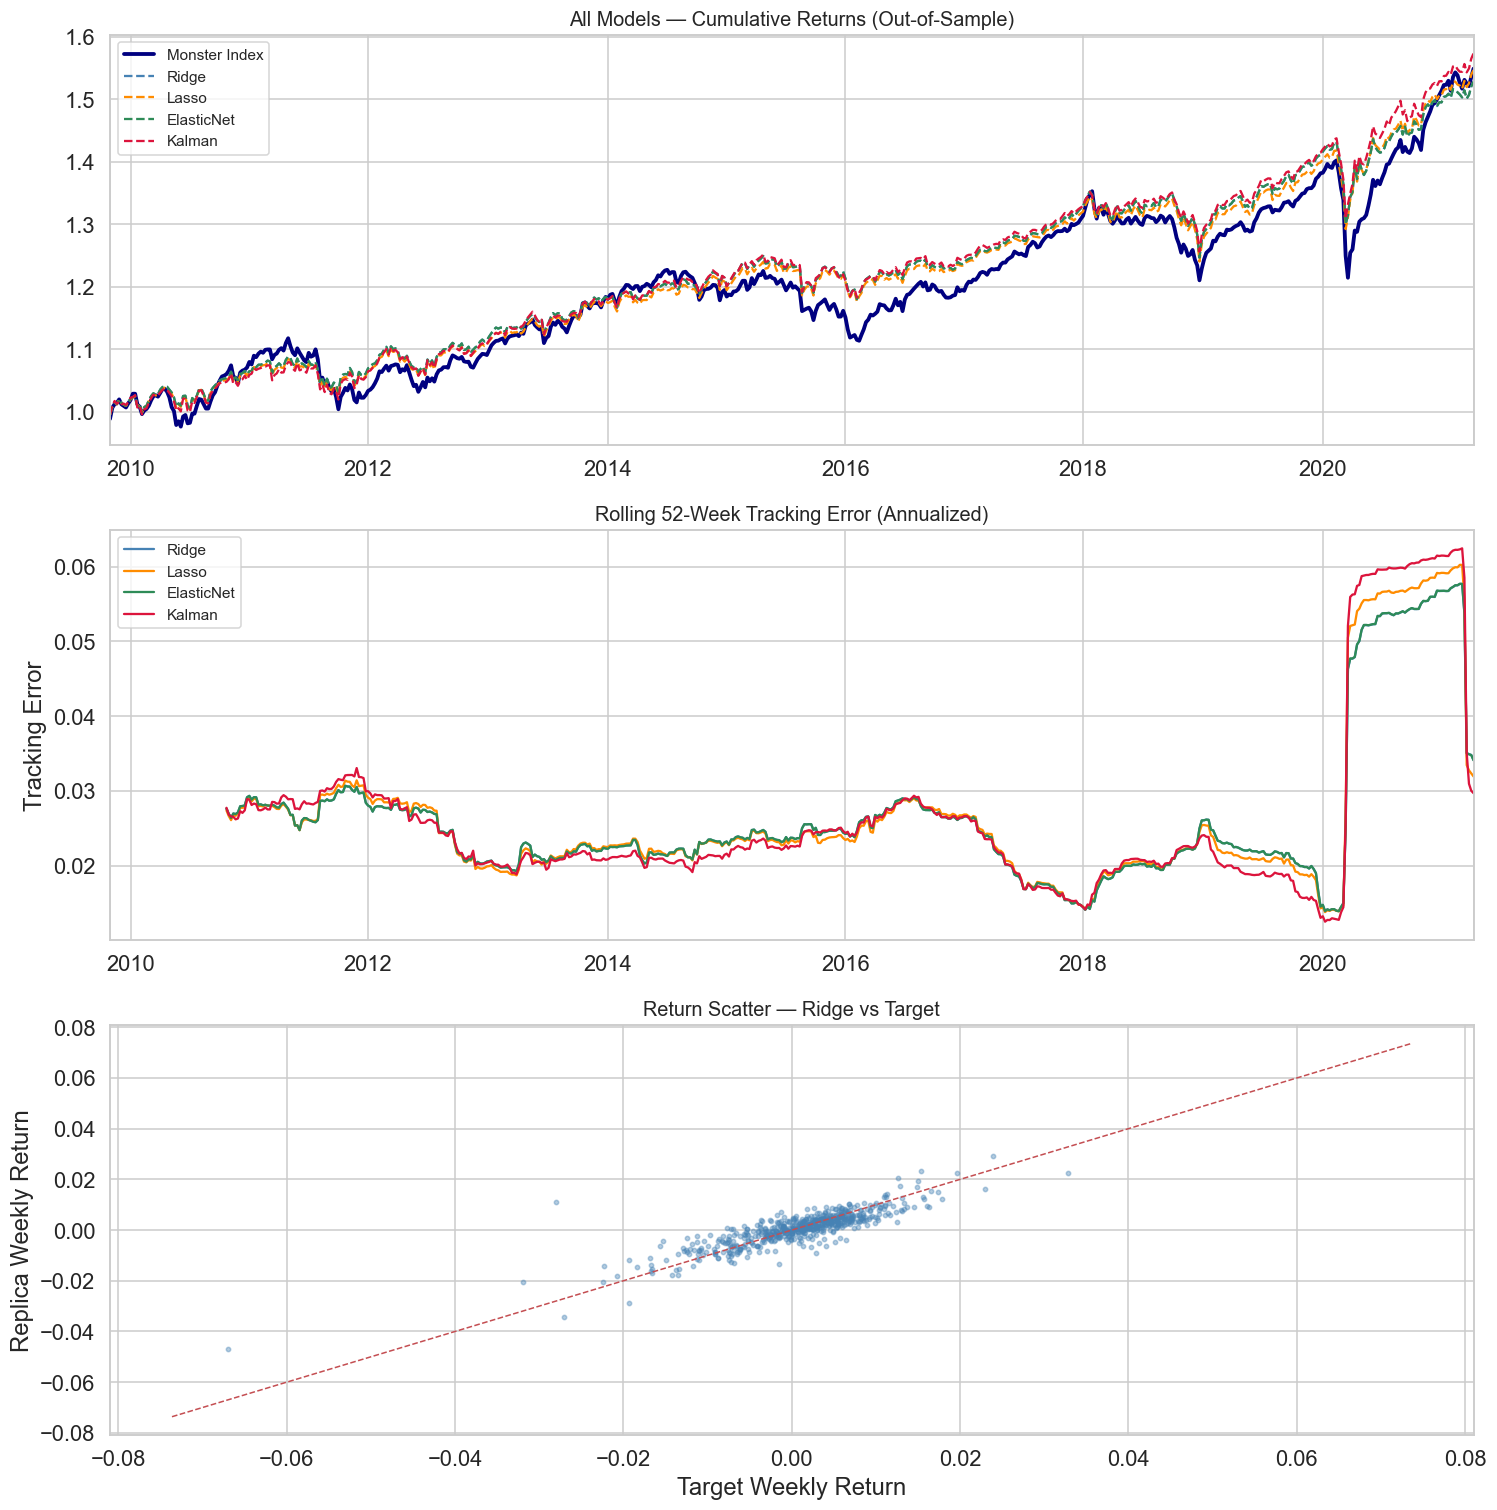

In [35]:
# ============================================================
# COMBINED CUMULATIVE RETURN CHART
# ============================================================

# ------------------------------------------------------------
# SAFE COMMON INDEX
# ------------------------------------------------------------
common_out = results[list(results.keys())[0]]["replica"].index

for res in results.values():
    common_out = common_out.intersection(res["replica"].index)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# ------------------------------------------------------------
# TARGET (SAFE ACCESS)
# ------------------------------------------------------------
first_res = next(iter(results.values()))

if "target" in first_res:
    target = first_res["target"].loc[common_out]
else:
    target = runner.y.loc[common_out]

target_cum = (1 + target).cumprod()
target_cum.plot(ax=axes[0], color='navy', lw=2.5, label='Monster Index')

# ------------------------------------------------------------
# CUMULATIVE RETURNS
# ------------------------------------------------------------
pal = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for (name, res), col in zip(results.items(), pal):
    (1 + res["replica"].loc[common_out]).cumprod().plot(
        ax=axes[0],
        lw=1.5,
        linestyle='--',
        color=col,
        label=name
    )

axes[0].set_title('All Models — Cumulative Returns (Out-of-Sample)', fontsize=13)
axes[0].legend(fontsize=10)

# ------------------------------------------------------------
# ROLLING TRACKING ERROR
# ------------------------------------------------------------
for (name, res), col in zip(results.items(), pal):

    rep = res["replica"].loc[common_out]

    if "target" in res:
        tgt = res["target"].loc[common_out]
    else:
        tgt = target

    roll_te = (rep - tgt).rolling(52).std() * np.sqrt(annual_factor)

    roll_te.plot(ax=axes[1], lw=1.5, color=col, label=name)

axes[1].set_title('Rolling 52-Week Tracking Error (Annualized)', fontsize=13)
axes[1].set_ylabel('Tracking Error')
axes[1].legend(fontsize=10)

# ------------------------------------------------------------
# SCATTER (BEST MODEL)
# ------------------------------------------------------------
best_name = all_metrics["Tracking Error (%)"].idxmin()
best_res = results[best_name]

rep = best_res["replica"].loc[common_out]

if "target" in best_res:
    tgt = best_res["target"].loc[common_out]
else:
    tgt = target

axes[2].scatter(tgt, rep, alpha=0.4, s=8, color='steelblue')

lim = max(abs(tgt).max(), abs(rep).max()) * 1.1

axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1)
axes[2].set_xlabel('Target Weekly Return')
axes[2].set_ylabel('Replica Weekly Return')
axes[2].set_title(f'Return Scatter — {best_name} vs Target', fontsize=13)

plt.tight_layout()
plt.show()

---

## 8. Transaction Costs & Rebalancing Frequency

Transaction costs matter — a strategy with excellent gross returns can be destroyed by high turnover. We analyze how rebalancing frequency affects net performance for the best model.

With Futures contracts, one-way costs are approximately **2–5 basis points** for a fund > €50M. We used 5bps as a conservative estimate. Here we show how net performance degrades with more frequent rebalancing.

In [38]:
# ============================================================
# REBALANCING FREQUENCY ANALYSIS
# ============================================================

# Reuse existing runner (IMPORTANT: do not recreate unless data changes)
#runner = ModelRunner(bt, futures_aligned, monster_aligned)

# Best model (only model hyperparameters here)
best_model = ElasticNet(
    alpha=best_params["alpha"],
    l1_ratio=best_params["l1_ratio"],
    fit_intercept=False,
    max_iter=100
)

# Backtest over different rebalance frequencies
rebal_table = runner.analyze_rebalancing(
    model=best_model,
    freqs=[1, 2, 4, 8, 13],
    rolling_window=104   # FIX: window is NOT in best_params
)

print('=== Net Performance vs Rebalancing Frequency ===')
display(rebal_table)

=== Net Performance vs Rebalancing Frequency ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
1,3.364,4.958,2.807,0.866,-0.181,1.883
2,3.565,4.977,2.859,0.861,-0.108,1.884
4,3.586,5.001,2.901,0.857,-0.099,1.888
8,3.676,5.038,2.895,0.858,-0.068,1.890
13,3.672,4.925,2.922,0.854,-0.069,1.876


`---

## 9. Summary & Conclusions

### 9.1 What we built

A complete portfolio replication pipeline that:
1. Constructs a synthetic non-investable target ("Monster Index") from hedge fund, equity, and bond indices
2. Attempts to replicate it using 11 liquid Futures contracts (equity, rates, commodities)
3. Implements four model classes: OLS (baseline), Ridge, Lasso, Elastic Net, and Kalman Filter
4. Applies a proper rolling backtest with no look-ahead bias
5. Enforces UCITS VaR constraints (Student-t, 99%, 1-month)
6. Accounts for transaction costs (5bps one-way) and rebalancing frequency

### 9.2 Key findings

| Finding | Implication |
|---|---|
| Fat tails in all series | Gaussian VaR underestimates risk — Student-t is more appropriate |
| Volatility clustering in squared returns | VaR is time-varying — static estimates miss crisis periods |
| HFRXGL has low correlation with tradable futures | Hedge fund replication is inherently imperfect — non-linear strategies cannot be fully cloned by linear models |
| Lasso produces sparser portfolios | Fewer positions → lower transaction costs, but higher tracking error |
| Kalman Filter adapts smoothly to regime changes | Better during crises but requires careful tuning of process/observation noise |
| Monthly rebalancing ~= weekly on net basis | Transaction costs from over-trading erode gross performance |

### 9.3 Limitations & Extensions

- **Non-linearity**: hedge funds use options and leverage. Linear models cannot fully capture their payoff structure. A neural network meta-model (Zenti's hint) could learn non-linear weight functions.
- **Regime detection**: incorporating a Hidden Markov Model or GARCH for regime-switching would allow different weight policies in crisis vs. calm markets.
- **Rollover costs**: Futures contracts expire and must be rolled — this generates additional costs not modeled here.
- **Currency effects**: all data is in local currency. In practice, FX exposure would need to be hedged separately.

In [42]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print('=' * 65)
print('FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS')
print('=' * 65)
display(all_metrics_net[[
    'Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe',
    'Tracking Error (%)', 'Correlation', 'Info Ratio',
    'Max Drawdown (%)', 'Avg Gross Exposure'
]].round(3))

best_net = all_metrics_net['Tracking Error (%)'].idxmin()
print(f'\n✅ Best model by Tracking Error: {best_net}')
best_corr = all_metrics_net['Correlation'].idxmax()
print(f'✅ Best model by Correlation: {best_corr}')

FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS


KeyError: "None of [Index(['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe', 'Tracking Error (%)',\n       'Correlation', 'Info Ratio', 'Max Drawdown (%)', 'Avg Gross Exposure'],\n      dtype='object')] are in the [columns]"